In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


# History file

In [2]:
# hst = np.loadtxt("../turb_template_2/parthenon.out1.hst", skiprows=1)
hst = np.loadtxt("/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.out1.hst", skiprows=1)

In [3]:
time = hst[:, 0]
KE = hst[:, 8]
mass = hst[:, 4]

In [4]:
vturb = np.sqrt(2*KE/ mass)
print("The root mean square velocity of the gas is: ", np.average(vturb[: -1000]))

The root mean square velocity of the gas is:  0.06919170994260852


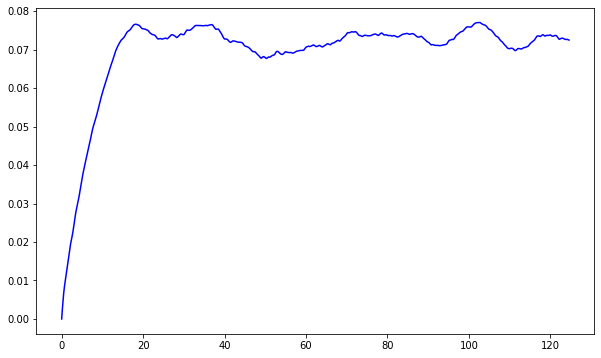

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(time, vturb, label="Turbulent Velocity", color='blue')

In [6]:
# vturb = 0.3
# vturb = 0.45
vturb = 0.07
Lbox = 1.0
rho = 0.25

In [7]:
# pdot = 0.5* rho * vturb**2 * Lbox**2
pdot = 0.5* vturb**2 / Lbox
print(pdot)

0.0024500000000000004


# HDF5 outputs

In [8]:
data_file = phdf.phdf("/ptmp/mpa/ankitad/athenapk/sim_nocool_gpu/parthenon.prim.00059.phdf")
data_file.Variables

['Blocks',
 'Info',
 'Input',
 'Levels',
 'Locations',
 'LogicalLocations',
 'Params',
 'VolumeLocations',
 'acc',
 'prim',
 'tracers']

In [9]:
prim = data_file.Get("prim", flatten=False)
np.shape(prim)

(64, 5, 32, 32, 32)

In [10]:
acc = data_file.Get("acc")
np.shape(acc)

(64, 3, 32768)

In [11]:
data_file

# Tracers

In [12]:
from pathlib import Path
import sys

sys.path.insert(
    1,
    "../external/parthenon" + "/scripts/python/packages/parthenon_tools/parthenon_tools",
)

try:
    import phdf
except ModuleNotFoundError:
    print("Couldn't find module to read Parthenon hdf5 files.")


In [25]:
filenames = [f"/ptmp/mpa/ankitad/athenapk/nc_256_05/parthenon.prim.{str(i).zfill(5)}.phdf" for i in range(10)] 

rho_list = []

for i, filename in enumerate(filenames):
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    xs = tracers.x
    ys = tracers.y
    zs = tracers.z
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    rho_list.append(rho)


In [26]:

# Concatenate all frames' tracer density
all_rho = np.concatenate(rho_list)

print("Tracer density stats:")
print(f"Mean: {np.mean(all_rho):.3e}")
print(f"Std : {np.std(all_rho):.3e}")
print(f"Min : {np.min(all_rho):.3e}")
print(f"Max : {np.max(all_rho):.3e}")


Tracer density stats:
Mean: 1.013e+00
Std : 1.138e-01
Min : 3.366e-01
Max : 1.786e+00


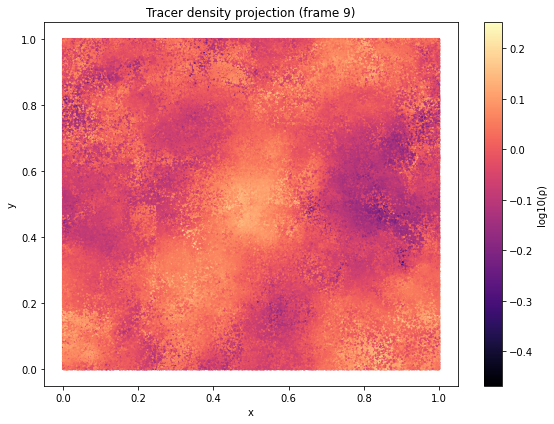

In [27]:

# Just take a single frame for now (e.g., frame 0)
frame = 9
data = phdf.phdf(filenames[frame])
tracers = data.GetSwarm("tracers")

x = tracers.x
y = tracers.y
rho = tracers.Get("rho")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=np.log10(rho), s=1, cmap='magma')
plt.colorbar(label='log10(ρ)')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Tracer density projection (frame {frame})')
plt.tight_layout()
plt.show()


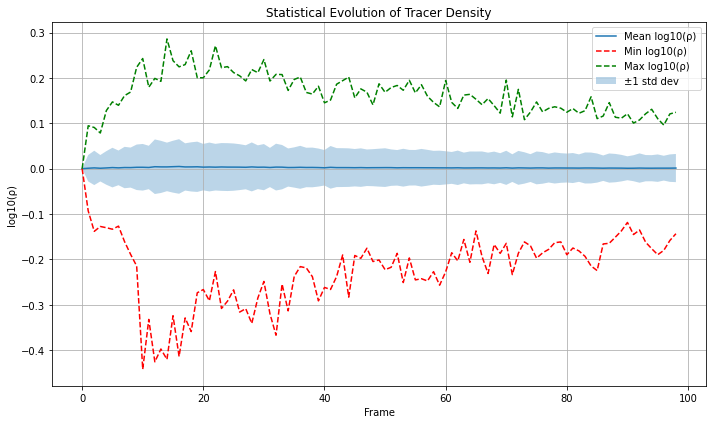

In [16]:
means = []
mins = []
maxs = []
stds = []

for rho in rho_list:
    log_rho = np.log10(rho)
    means.append(np.mean(log_rho))
    mins.append(np.min(log_rho))
    maxs.append(np.max(log_rho))
    stds.append(np.std(log_rho))

frames = np.arange(len(rho_list))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(frames, means, label='Mean log10(ρ)')
plt.fill_between(frames, np.array(means)-np.array(stds), np.array(means)+np.array(stds),
                 alpha=0.3, label='±1 std dev')
plt.plot(frames, mins, '--', label='Min log10(ρ)', color='red')
plt.plot(frames, maxs, '--', label='Max log10(ρ)', color='green')

plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Statistical Evolution of Tracer Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Selected tracer IDs: [40513]


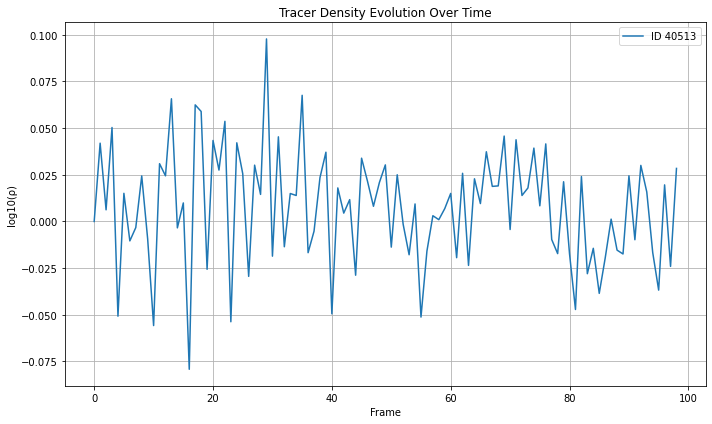

In [17]:
data0 = phdf.phdf(filenames[0])
tracers0 = data0.GetSwarm("tracers")
ids0 = tracers0.Get("id")

import numpy as np
selected_ids = np.random.choice(ids0, size=1, replace=False)
print("Selected tracer IDs:", selected_ids)

# Initialize storage
id_rho_dict = {tid: [] for tid in selected_ids}

for filename in filenames:
    data = phdf.phdf(filename)
    tracers = data.GetSwarm("tracers")
    ids = tracers.Get("id")
    rho = tracers.Get("rho")

    for tid in selected_ids:
        match = np.where(ids == tid)[0]
        if len(match) == 1:
            id_rho_dict[tid].append(np.log10(rho[match[0]]))  # log scale
        else:
            id_rho_dict[tid].append(np.nan)


plt.figure(figsize=(10, 6))
for tid, log_rhos in id_rho_dict.items():
    plt.plot(log_rhos, label=f'ID {tid}')
plt.xlabel('Frame')
plt.ylabel('log10(ρ)')
plt.title('Tracer Density Evolution Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
